In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Util

In [2]:
def plotDuffing(t, x, v, skip_t=0, title='', delta=None, alpha=None, beta=None, gamma=None, omega=None):
    """
    Plot a duffing eqaution in time and phase space.
    
    Parameters:
        t (np.ndarray): time vector
        x (np.ndarray): displacment vector
        v (np.ndarray): velocity vector
        skip_t (float): If 0 < skip_t < 1: skips int(skip_t*len(t)) of values
                        If 1 < skip_t: skips int(skip_t*kl) values
        title (str): title
        delta, alpha, beta, gamma, omega (float): duffing parameters
    """


    if omega is not None:
        t_periode, kl = computePeriode(omega, t[1] - t[0])
    else:
        kl = None

    idx_start = steadyState(skip_t, len(t), kl)

    fig, [ax0, ax1] = plt.subplots(2)
    if t_periode is not None:
        ax0.plot(t[idx_start:]/t_periode, x[idx_start:])
        ax0.set_xlabel('$t/T$')
    else:
        ax0.plot(t[idx_start:], x[idx_start:])
        ax0.set_xlabel('$t$')
    ax0.set_ylabel('$x(t)$')
    ax0.grid()
    ax0.set_title('')
    if kl is not None:
        idx = np.array(np.arange(idx_start, len(t), kl), dtype=int)
        ax1.scatter(x[idx], v[idx], c='orange', marker='x')
    ax1.plot(x[idx_start:], v[idx_start:])
    ax1.set_xlabel('$x(t)$')
    ax1.set_ylabel('$\dot{x}(t)$')
    ax1.grid()
    fig.tight_layout(h_pad=0.75, pad=2)
    text = title + fr'$\delta={delta}; \alpha={alpha}; \beta={beta}; \gamma={gamma}; \omega={omega}$'
    fig.suptitle(text)

def computePeriode(omega, h):
    t_periode = 2 * np.pi / omega
    kl = t_periode / h
    return t_periode, kl

def steadyState(skip_t, nTimeSteps, kl):
    if skip_t <= 0:
        idx_start = 0   
    elif 0 < skip_t < 1:
        idx_start = int(skip_t * nTimeSteps)
    elif 1 <= skip_t and kl is not None:
        idx_start = int(skip_t * kl)
    else:
        raise ValueError(f'Value skip_t={skip_t} not possible with kl={kl}')
    
    return idx_start

# Duffing Equation

The Duffing equation is a non-linear second-order differential equation given by:

$$ \ddot{x} + \delta \dot{x} + \alpha x + \beta x^3 = \gamma \cos(\omega t) $$

where:
- $ \ddot{x} $ is the acceleration (second derivative of $ x $ with respect to time).
- $ \dot{x} $ is the velocity (first derivative of $ x $ with respect to time).
- $ \delta $ is the damping coefficient.
- $ \alpha $ and $ \beta $ are stiffness parameters.
- $ \gamma $ is the amplitude of the periodic driving force.
- $ \omega $ is the angular frequency of the periodic driving force.

The simplified Duffing equation, considering only the terms involving $b$ and $ \gamma $, is given by:

$$ \ddot{x} + b\dot{x} - x + x^3 = \gamma \cos(t) $$

In [3]:
def duffing(t, y, delta, alpha, beta, gamma, omega):
    x, x_dot = y
    y_dot = [
        x_dot, 
        -delta * x_dot - alpha * x - beta * x**3 + gamma * np.cos(omega * t),
        ]
    return y_dot

In [35]:
delta = 0.3
alpha = -1.0
beta = 1.0
omega = 1.2     # must be constant for all cases, due to calculations
parametersChaos = {
    'delta': delta,
    'alpha': alpha,
    'beta': beta,
    'gamma': 0.5,
    'omega': omega,
}
parameters = {
    'delta': delta,
    'alpha': alpha,
    'beta': beta,
    'gamma': 0.37,
    'omega': omega,
}

y0 = [1.0, 0.0]                                     # initial conditions: [x0, x_dot0]
h = 0.001                                            # time step
t_periode, kl = computePeriode(omega, h)            # periode of driving force
n_periodes = 40                                     # number of periodes
t_span = [0, n_periodes * t_periode]                # time span
t_eval = np.linspace(t_span[0], t_span[1], n_periodes*int(kl))  # time points where the solution is computed
skip_t = 20             # number of skipped periodes if skip_t>1 else percentage of skipped values

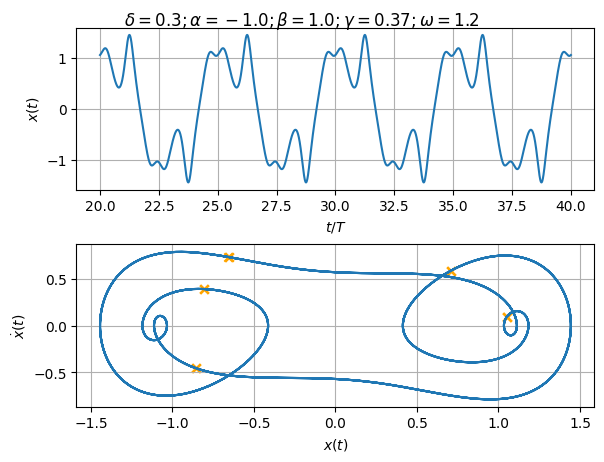

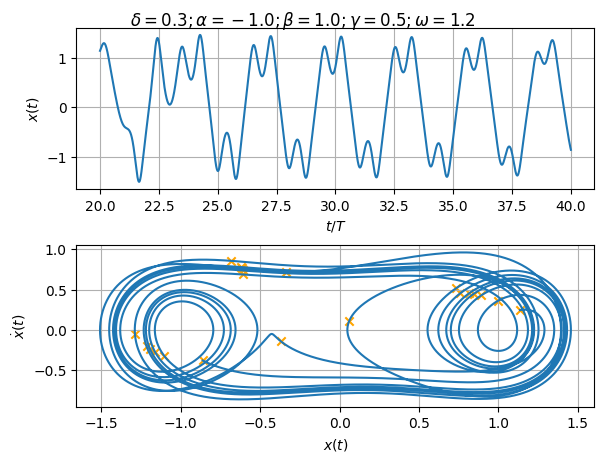

In [5]:
sol = solve_ivp(duffing, t_span, y0, args=parameters.values(), t_eval=t_eval)
plotDuffing(sol.t, sol.y[0], sol.y[1], skip_t=skip_t, **parameters)
solChaos = solve_ivp(duffing, t_span, y0, args=parametersChaos.values(), t_eval=t_eval)
plotDuffing(solChaos.t, solChaos.y[0], solChaos.y[1], skip_t=skip_t, **parametersChaos)

# Test for Chaos

## Lyapunov Exponent (not working)
"
1. Iterate until the orbit is on the attractor or start with an initial point known to be on the attractor.
2. Choose an arbitrary point $a_0$ from the phase space trajectory;
3. Choose or imagine point $b_0$ as a nearby point separated by $d_0$ (a suitable value for $d_0$ is about 1000 times larger than the precision of the floating point number being used);
4. Iterate both points and calculate the new distance of the two selected points in Steps 2 and 3 $(a_1, b_1)$   
$ d_1 = \sqrt{{(x_{a1} − x_{b1})}^{2} + {(y_{a1} − y_{b1})}^{2}} $.
5. Calculate the equation   
$LD = log \frac{d_1}{d_0}$;
6. Readjust the second point so its separation is $d_0$ in the same direction as that of $d_1$   
$ \begin{cases} x_{b0} = x_{a1} + \frac{d_0}{d_1} (x_{b0} - x_{a0}) \\ y_{b0} = y_{a1} + \frac{d_0}{d_1} (y_{b0} - y_{a0}) \end{cases} $ 
7. Repeat Steps 4–6 and the $LLE$ is the average
of the $LD$.

"

[Detecting the state of the duffing Oscillator by phase space trajectory autocorrelation, Vahid Rashtchi and Mohsen Nourazar]

In [6]:
def duffing_perturbation(t, y, delta, alpha, beta, gamma, omega, d0):
    x, x_dot, xp, xp_dot = y

    y_dot = duffing(t, (x, x_dot), delta, alpha, beta, gamma, omega)
    
    yp_dot = duffing(t, (xp, xp_dot), delta, alpha, beta, gamma, omega)

    d = [
        yp_dot[0] - y_dot[0],
        yp_dot[1] - y_dot[1],
    ]

    d_norm = np.linalg.norm(d)

    yp_dot_norm = [
        y_dot[0] + d[0] * d0/d_norm,
        y_dot[1] + d[1] * d0/d_norm,
    ]

    return y_dot + yp_dot_norm

def lle(y, yp, d0, skip_t=0, omega=None, h=None):
    if omega is not None and h is not None:
        _, kl = computePeriode(omega, h)
    else:
        kl = None
        
    idx_start = steadyState(skip_t, len(y), kl)

    le = np.log(np.linalg.norm(y[:,idx_start:] - yp[:,idx_start:], axis=0) / d0)
    return le, np.mean(le)

As seen below, even the obviously periodic solution is detected as chaotic. Therefore this methode does not work or was not implemented correctly.

In [7]:
d0 = 1000 * 1e-16       # perturbation for largest lyapunov exponent
y0p = y0 + y0           # initial condition
y0p[2] -= d0

sol = solve_ivp(duffing_perturbation, t_span, y0p, args=dict(parameters, **{'d0': d0}).values(), t_eval=t_eval)
solChaos = solve_ivp(duffing_perturbation, t_span, y0p, args=dict(parametersChaos, **{'d0': d0}).values(), t_eval=t_eval)

le_series, mean_le = lle(sol.y[:2], sol.y[2:], d0, skip_t=skip_t, omega=omega, h=h)
le_series_chaos, mean_le_chaos = lle(solChaos.y[:2], solChaos.y[2:], d0, skip_t=skip_t, omega=omega, h=h)

# This is not correct?!
print('sol is chaotic: ', 0 < mean_le)
print('solChaos is chaotic: ',0 < mean_le_chaos)

sol is chaotic:  True
solChaos is chaotic:  True


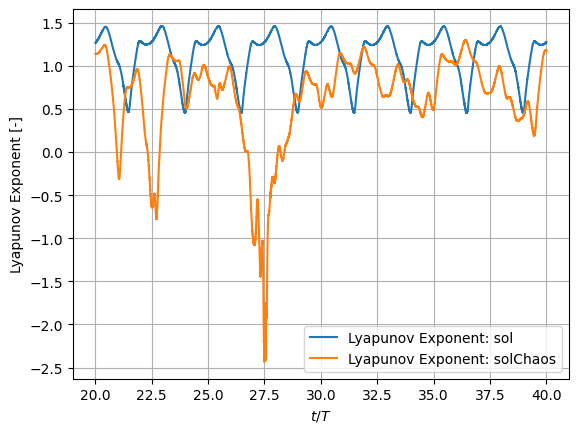

In [8]:
idx_start = steadyState(skip_t, len(sol.t), kl)
plt.plot(sol.t[idx_start:] / t_periode, le_series)
plt.plot(solChaos.t[idx_start:] / t_periode, le_series_chaos)
plt.grid()
plt.ylabel('Lyapunov Exponent [-]')
plt.xlabel('$t/T$')
plt.legend(['Lyapunov Exponent: sol', 'Lyapunov Exponent: solChaos'])

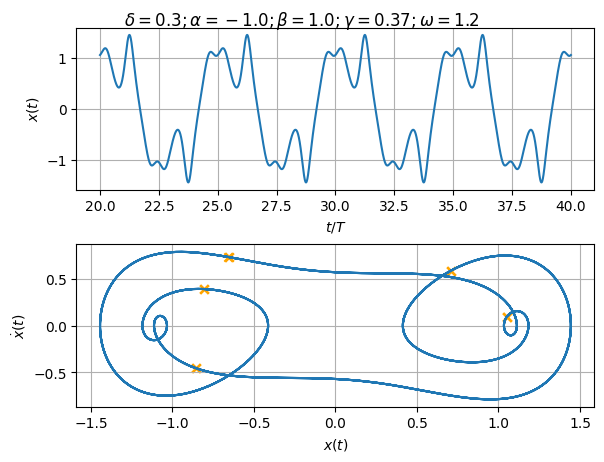

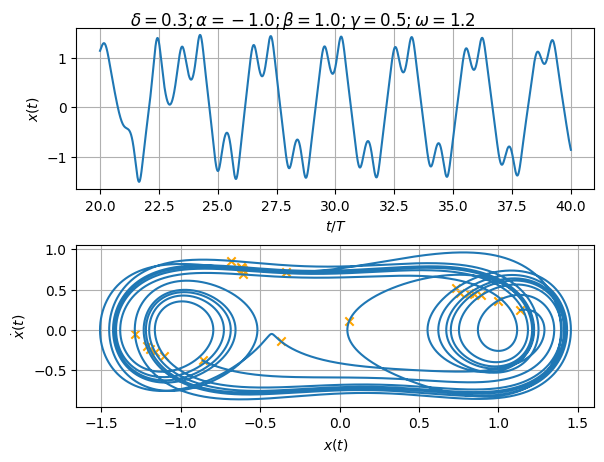

In [9]:
# Verify the solution is valid
plotDuffing(sol.t, sol.y[0], sol.y[1], skip_t=skip_t, **parameters)
plotDuffing(solChaos.t, solChaos.y[0], solChaos.y[1], skip_t=skip_t, **parametersChaos)

## Autokorrelation on Time Series
To test a solution of the Duffing Oscillator for chaos the autocorrelation on the Phase
Space Trajectory is calculated. The autocorrelation is given by 
$$r_x(kl) = \frac{\sum_{i=n_1}^{n_1+kl} (x_i - \bar{x}_1)(x_{i+kl} - \bar{x}_2)}{\sqrt{\sum_{i=n_1}^{n_1+kl} (x_i - \bar{x}_1)^2 \sum_{i=n_1}^{n_1+kl} (x_{i+kl} - \bar{x}_2)^2}},$$
"where $\bar{x}_1$ is the mean of the first $kl$ sample, $\bar{x}_1$ the
mean of the next kl sample and n1 is an arbitrary initial point for autocorrelation. For calculating the autocorrelation of two periods of phase space trajectory, the value of kl should be equal to the number of samples in one orbit (an orbit is one period of the driving force):
$$ kl = \frac{\frac{2 \pi}{\omega_0}}{h} = \frac{T_0}{h} $$
where $\omega_0$ is the frequency of the driving force, $T_0$ is the period of driving force and h is the step size in the numerical solution of the equations of the Duffing oscillator."

[Detecting the state of the duffing Oscillator by phase space trajectory autocorrelation, Vahid Rashtchi and Mohsen Nourazar]

In [10]:
def periodicCorrelation(x, skip_t, omega, h, periodeFactor=1):

    _, kl = computePeriode(omega, h)
    multiperiode = periodeFactor * kl

    idx_start = steadyState(skip_t, len(x), kl)

    idx = np.array(np.arange(idx_start, len(x), multiperiode), dtype=int)
    iterations = len(idx)-1
    r = np.zeros([iterations])

    for i in range(iterations):
        xi = x[idx[i] : idx[i] + int(multiperiode)]
        xi_kl = x[idx[i+1] : idx[i+1] + int(multiperiode)]
        min_length = len(xi_kl) if len(xi_kl) < len(xi) else len(xi)
        zi = xi[:min_length] - np.mean(xi[:min_length])
        zi_kl = xi_kl[:min_length] - np.mean(xi_kl[:min_length])
        r[i] = np.sum(zi * zi_kl) / (np.sqrt(np.sum(zi**2) * np.sum(zi_kl**2)))
    return r

def isChaosPeriodicCorrelationThreshold(correlation):
    correlation_threshold = 0.98
    window_threshold = 0.9
    return np.sum(correlation > correlation_threshold) / len(correlation) < window_threshold

def isPeriodic(x, skip_t, omega, h, maxPeriodeFactor=1):
    for i in range(1, maxPeriodeFactor):

        r = periodicCorrelation(x, skip_t, omega, h, i)
        isChaos = isChaosPeriodicCorrelationThreshold(r)
        if not isChaos:
            # Warn if short signal
            idx_start = steadyState(skip_t, len(x), kl)
            length = len(x) - idx_start
            fractionPeriodes = length / int(i * kl)
            if fractionPeriodes - 1 < 1:
                print((
                    f'The signal was tested only on a fraction '
                    f'k={fractionPeriodes-1} of the tested periode.'
                    )
                )
            return i
    return False

def isChaotic(x, skip_t, omega, h, maxPeriodeFactor=1):
    if isPeriodic(x, skip_t, omega, h, maxPeriodeFactor):
        return True
    return False

In [11]:
print(f'sol is not periodic (=chaotic): {isChaotic(sol.y[0], skip_t, omega, h, 10)}')
print(f'solChaos is not periodic (=chaotic): {isChaotic(solChaos.y[0], skip_t, omega, h, 10)}')

sol is not periodic (=chaotic): True
solChaos is not periodic (=chaotic): False


Testing for periodicity is possible even if the time series in steady state is shorter than the tested periode length. There may be inaccuracies due to only testing a fraction of a periode. The example below shows that 33% of a periode are sufficient to detect periodicity.

Signal is periodic with n=5 times periode.
Signal is periodic with n=10 times periode.
The signal was tested only on a fraction k=0.9992933402089421 of the tested periode.
Signal is periodic with n=15 times periode.
The signal was tested only on a fraction k=0.33285374145329083 of the tested periode.


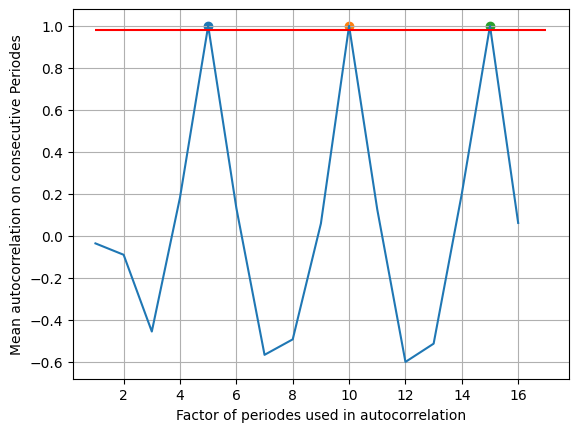

In [12]:
k = 16
signal = sol.y[0]
chaotic = np.zeros([k], dtype=bool)
correlation = np.zeros([k])
for i in range(1, k+1):
    r = periodicCorrelation(signal, skip_t, omega, h, i)
    correlation[i-1] = np.mean(r)
    if not isChaosPeriodicCorrelationThreshold(r):
        print(f'Signal is periodic with n={i} times periode.')
        idx_start = steadyState(skip_t, len(signal), kl)
        length = len(signal) - idx_start
        fractionPeriodes = length / int(i * kl)
        if fractionPeriodes - 1 < 1:
            print((
                f'The signal was tested only on a fraction '
                f'k={fractionPeriodes-1} of the tested periode.'
                )
            )
        plt.scatter(i, correlation[i-1])


plt.plot(range(1, k+1), correlation)#, label=f'n={i} is chaotic: {chaotic}')
plt.hlines(0.98, xmin=1, xmax=k+1, colors='red')
plt.grid()
# plt.legend()
plt.xlabel('Factor of periodes used in autocorrelation')
plt.ylabel('Mean autocorrelation on consecutive Periodes')
plt.show()

For different values of $\gamma$ the periodicity is will be plotted. Periodicity occures if a solution is periodic with $T_n = n * 2\pi/\omega$ where $n$ is a value between 1 and 30. By this definition a solution is chaotic, if no periodicity is detected. Choas is visualized with a value of $n=0$ in the plot below.

Text(0, 0.5, 'periodicity $n$ for $T_n = n * 2\\pi/\\omega$')

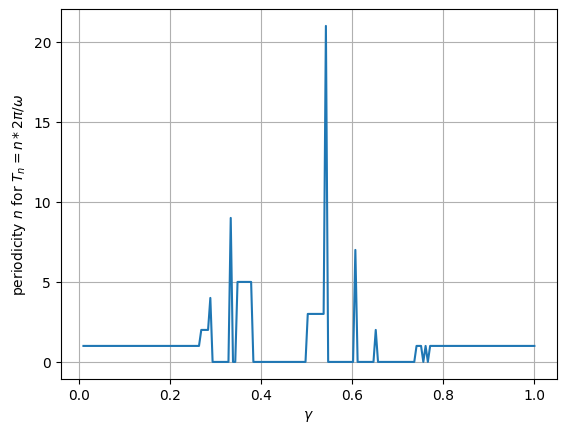

In [ ]:
parametersGamma = {
    'delta': delta,
    'alpha': alpha,
    'beta': beta,
    'gamma': 0,
    'omega': omega,
}

n_periodes = 110
t_span = [0, n_periodes * t_periode]
t_eval = np.linspace(t_span[0], t_span[1], n_periodes*int(kl))

gamma_values = np.linspace(0.01, 1, 200)
periodic = np.zeros(gamma_values.shape)

for idx, c in enumerate(gamma_values):
    parametersGamma['gamma'] = c
    solPeriodic = solve_ivp(duffing, t_span, y0, args=parametersGamma.values(), t_eval=t_eval)
    # maxPeriodeFactor = int((n_periodes - skip_t) / 2)    # 110 - 20 / 3 = 30 -> every simulation 3
    periodic[idx] = isPeriodic(solPeriodic.y[0], skip_t, omega, h, maxPeriodeFactor=30)
    if periodic[idx] > 20:
        solSafe = solPeriodic
        parametersSafe = parametersGamma.copy()

plt.plot(gamma_values, periodic)
plt.grid()
plt.xlabel('$\gamma$')
plt.ylabel('periodicity $n$ for $T_n = n * 2\pi/\omega$')
plt.show()

There might be outliers, for example $\gamma\approx0.54$. A visualization is given below and the correlation of proceeding periodes are printed:

Correlation of proceeding periodes:
[0.982, 0.994, 0.984, 0.998]


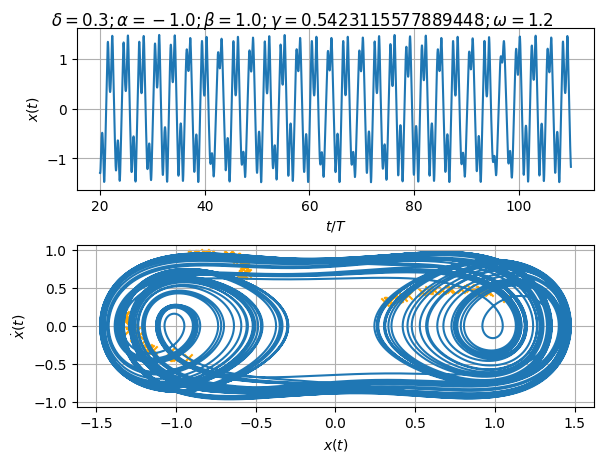

In [73]:
plotDuffing(solSafe.t, solSafe.y[0], solSafe.y[1], skip_t, **parametersSafe)
print("Correlation of proceeding periodes:")
r = periodicCorrelation(solSafe.y[0], skip_t, parametersSafe['omega'], h, periodeFactor=21)
print([round(v, 3) for v in r])